In [11]:
import numpy as np
import pandas as pd

df = pd.read_parquet('../data/processed/icm_features.parquet')
print(df.shape)
print(df.columns.tolist())

(288, 11)
['fecha', 'valor', 'valor_icm_clean', 'mes', 'anyo', 'es_navidad', 'es_rebajas', 'lag_1', 'lag_12', 'rolling_mean_3', 'valor_ipc']


## Baseline

In [15]:
from src.functions import walk_forward_validation, naive_seasonal

serie = df.set_index('fecha')['valor_icm_clean']
serie.index.freq = serie.index.inferred_freq

resultado_naive = walk_forward_validation(
    serie=serie,
    modelo_func=naive_seasonal,
    min_train=96,
    horizonte=3
)

print(f"Baseline Naive Seasonal:")
print(f"MAPE medio: {resultado_naive['mape_medio']:.4f}")
print(f"MAPE std: {resultado_naive['mape_std']:.4f}")
print(f"Ventanas evaluadas: {resultado_naive['n_ventanas']}")

Baseline Naive Seasonal:
MAPE medio: 0.0373
MAPE std: 0.0268
Ventanas evaluadas: 64


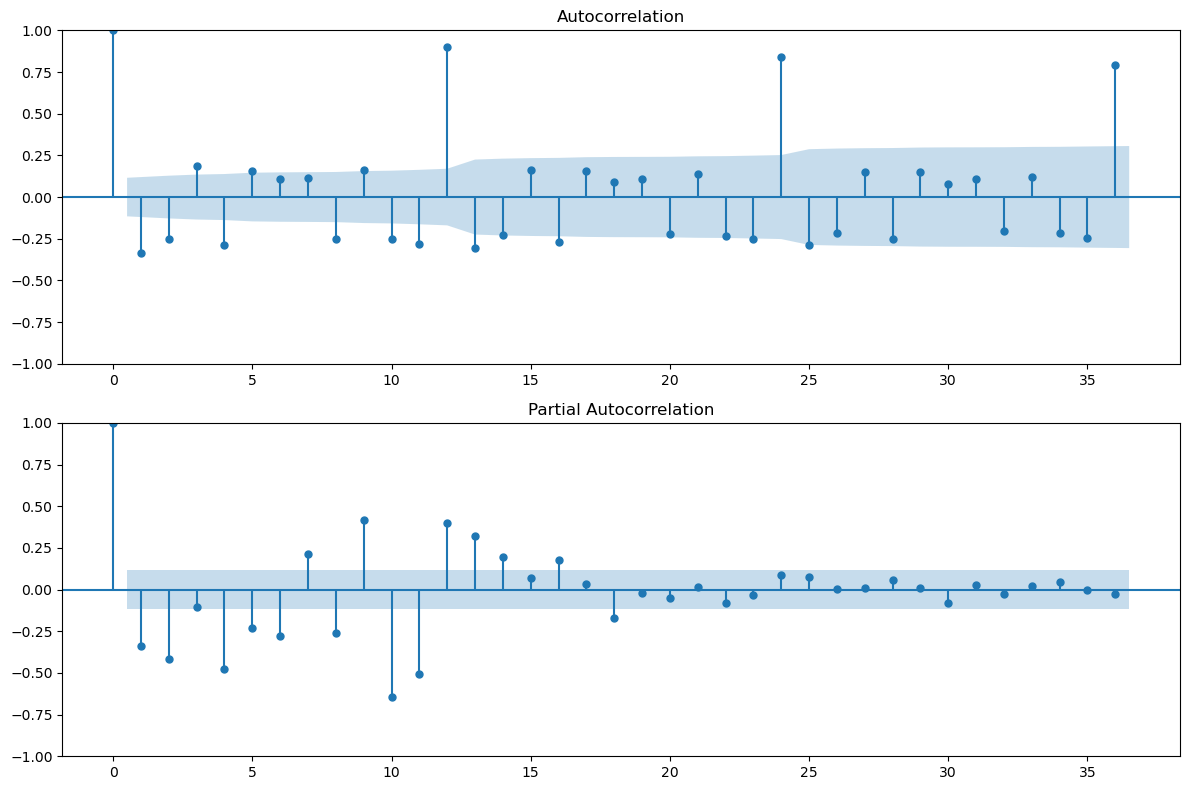

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['valor_icm_clean'].diff().dropna(), lags=36, ax=axes[0])
plot_pacf(df['valor_icm_clean'].diff().dropna(), lags=36, ax=axes[1])

plt.tight_layout()
plt.savefig('../reports/figures/06_acf_pacf.png', dpi=150)
plt.show()

In [4]:
from pmdarima import auto_arima

modelo_auto = auto_arima(
    df['valor_icm_clean'],
    seasonal=True,
    m=12,
    d=1,
    D=1,
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

print(modelo_auto.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  288
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -651.944
Date:                            Thu, 18 Jun 2026   AIC                           1313.889
Time:                                    23:04:34   BIC                           1331.973
Sample:                                         0   HQIC                          1321.146
                                            - 288                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9095      0.113     -8.016      0.000      -1.132      -0.687
ar.L2         -0.5134      0.054   

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarima_model(train, horizonte):
    modelo = SARIMAX(
        train,
        order=(2, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    resultado = modelo.fit(disp=False)
    predicciones = resultado.forecast(steps=horizonte)
    return predicciones.values

resultado_sarima = walk_forward_validation(
    serie=serie,
    modelo_func=sarima_model,
    min_train=96,
    horizonte=3
)

print(f"SARIMA:")
print(f"MAPE medio: {resultado_sarima['mape_medio']:.4f}")
print(f"MAPE std: {resultado_sarima['mape_std']:.4f}")

SARIMA:
MAPE medio: 0.0205
MAPE std: 0.0165
